# 09. ZZ_나머지와 제외 업종

**이 노트북이 하는 일**
업종 분류가 안 된 `ZZ_나머지`의 **건당 금액과 법인 비중을 지역별로** 정리한다.

`ZZ_나머지`는 데이터1 금액의 약 26%를 차지해서 01번에서 분석 대상에서 뺐다(01번 1-6).
그런데 01번은 이걸 **전체 기준**으로만 봤다. 여기서는 강남과 춘천을 쪼개서, **두 지역의 ZZ가 같은 것인지** 확인한다.
같은 것이 아니라면 "ZZ를 뺀다"는 하나의 결정이 두 지역에 서로 다르게 작용하게 되고, 이는 Q9(두 지역 비교)의 전제와 부딪친다.

**답해야 할 질문**
1. ZZ_나머지의 금액 비중, 건수 비중, 건당 금액은 두 지역에서 같은가?
2. 법인 비중은 어떤가? 나머지 업종과 비교하면?
3. 언제, 누가 쓰는 결제인가? (시간대, 연령, 요일, 거주지)
4. 다른 제외 업종과 견주면 ZZ만의 특징은 무엇인가?

**입력과 출력**
| 입력 (`notebooks/preprocessed/`) | 만든 노트북 |
|---|---|
| `card1.parquet`, `card2.parquet`, `calendar.parquet`, `industry_map.csv` | 01 |

출력: 표와 그림. 저장하는 파일은 없다.

## 0. 준비

### 0-1. 라이브러리 불러오기와 그래프 기본 설정

In [1]:
from pathlib import Path          # 파일 경로 다루기 (윈도우/맥 상관없이 동작)
import numpy as np                # 숫자 계산
import pandas as pd               # 표(DataFrame) 다루기
import matplotlib.pyplot as plt   # 그래프 그리기
from IPython.display import display   # 표를 칸이 나뉜 표로 보여줌

# ── 한글 폰트 설정 (안 하면 그래프의 한글이 네모로 깨짐) ──
plt.rc('font', family='Malgun Gothic')     # 윈도우 기본 한글 폰트
plt.rc('axes', unicode_minus=False)        # 음수 부호(-)가 깨지는 것 방지

plt.rc('figure', figsize=(9, 4), dpi=110)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 40)

### 0-2. 경로 설정과 데이터 불러오기

In [2]:
# 01번 노트북과 같은 방식으로 프로젝트 맨 위 폴더를 찾는다.
ROOT = Path.cwd()
while not (ROOT / 'dataset').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('dataset 폴더를 찾을 수 없다. 노트북 위치를 확인한다.')
    ROOT = ROOT.parent
OUT = ROOT / 'notebooks' / 'preprocessed'

card1 = pd.read_parquet(OUT / 'card1.parquet')          # 데이터1: 날짜 x 지역 x 업종 x 성별 x 연령 x 시간대
card2 = pd.read_parquet(OUT / 'card2.parquet')          # 데이터2: 날짜 x 지역 x 업종 x 성별 x 연령 x 거주지
calendar = pd.read_parquet(OUT / 'calendar.parquet')    # 달력 (요일, 공휴일)
imap = pd.read_csv(OUT / 'industry_map.csv')            # 업종 -> 업종그룹, 분석대상 여부

for name, df in {'card1': card1, 'card2': card2}.items():
    print(f'{name:7s} {df.shape[0]:>10,}행 x {df.shape[1]:>2}열')

card1    1,044,710행 x 11열
card2    1,806,800행 x 11열


### 0-3. 분석 기본 표 만들기
`ZZ_나머지`와 나머지 업종을 갈라 두고 시작한다. 법인은 빼지 않는다. **법인 비중 자체가 이 노트북의 관심사**이기 때문이다.

In [3]:
개인 = card1[card1['sex'] != '법인'].copy()          # 1장 표에서 '개인만' 줄을 만들 때 쓴다

z = card1[card1['industry'] == 'ZZ_나머지'].copy()   # ZZ_나머지
기타 = card1[card1['industry'] != 'ZZ_나머지'].copy()  # 나머지 업종 전체
z['건당'] = z['amount'] / z['cnt']
기타['건당'] = 기타['amount'] / 기타['cnt']

print(f'ZZ_나머지 {len(z):,}행 / 나머지 업종 {len(기타):,}행')
print(f'ZZ_나머지가 데이터1 금액에서 차지하는 비중: {z["amount"].sum() / card1["amount"].sum():.1%}')


ZZ_나머지 23,500행 / 나머지 업종 1,021,210행


ZZ_나머지가 데이터1 금액에서 차지하는 비중: 26.1%


## 1. 규모: 금액 비중, 건수 비중, 건당 금액


In [4]:
def zz표(df, label):
    전체 = df.groupby('region').agg(금액=('amount', 'sum'), 건수=('cnt', 'sum'))
    zz = df[df['industry'] == 'ZZ_나머지'].groupby('region').agg(금액=('amount', 'sum'), 건수=('cnt', 'sum'))
    return pd.DataFrame({
        'ZZ 금액 비중(%)': (zz['금액'] / 전체['금액'] * 100).round(1),
        'ZZ 건수 비중(%)': (zz['건수'] / 전체['건수'] * 100).round(1),
        'ZZ 건당 금액(원)': (zz['금액'] / zz['건수']).round(0),
        '전체 건당 금액(원)': (전체['금액'] / 전체['건수']).round(0),
        'ZZ / 전체 건당 배수': (zz['금액'] / zz['건수'] / (전체['금액'] / 전체['건수'])).round(1),
    }).assign(구분=label).set_index('구분', append=True)

display(pd.concat([zz표(card1, '법인 포함'), zz표(개인, '개인만')]).sort_index())

ZZ 금액 비중(%)  ZZ 건수 비중(%)  ZZ 건당 금액(원)  전체 건당 금액(원)  \
region 구분                                                          
강남     개인만          21.30        18.70    61,390.00    53,913.00   
       법인 포함        26.30        18.30    85,788.00    59,905.00   
춘천     개인만          24.80         3.20   317,734.00    40,466.00   
       법인 포함        24.40         3.20   337,783.00    44,556.00   

              ZZ / 전체 건당 배수  
region 구분                    
강남     개인만             1.10  
       법인 포함           1.40  
춘천     개인만             7.90  
       법인 포함           7.60

## 2. 건당 금액의 분포
합계로 낸 건당 금액은 **초대형 결제 몇 건에 끌려간다.** 표의 **행마다** 건당 금액(`amount / cnt`)을 구해 분포를 본다.

count       25%       50%       75%          95%  \
region 구분                                                                
강남     ZZ_나머지     13,605.00 22,782.00 38,368.00 62,846.00   205,987.00   
       나머지 업종 전체 648,123.00 11,773.00 29,431.00 85,732.00   462,424.00   
춘천     ZZ_나머지      9,895.00  3,924.00 12,105.00 58,672.00 1,653,875.00   
       나머지 업종 전체 373,087.00 11,462.00 26,691.00 54,960.00   247,198.00   

                            max  
region 구분                        
강남     ZZ_나머지     31,992,188.00  
       나머지 업종 전체 248,562,486.00  
춘천     ZZ_나머지     50,630,160.00  
       나머지 업종 전체  24,648,480.00

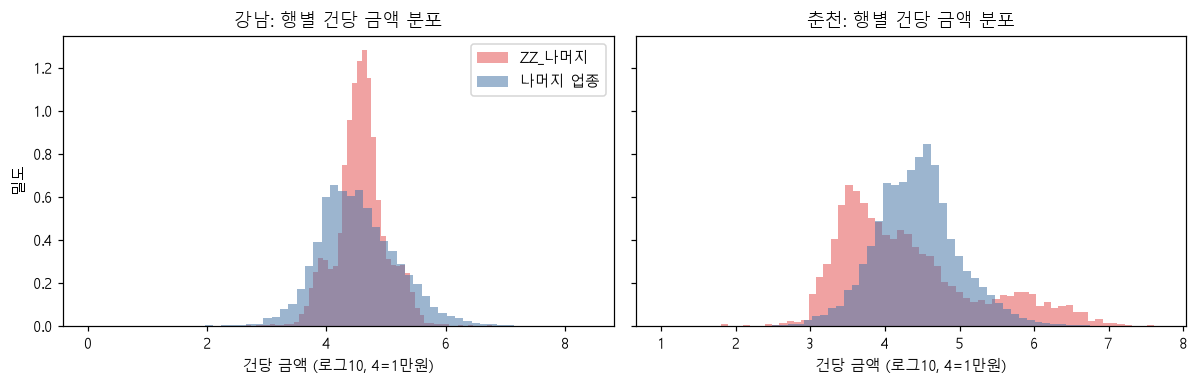

In [5]:
분위 = pd.concat([
    z.groupby('region')['건당'].describe(percentiles=[.25, .5, .75, .95]).assign(구분='ZZ_나머지'),
    기타.groupby('region')['건당'].describe(percentiles=[.25, .5, .75, .95]).assign(구분='나머지 업종 전체'),
]).set_index('구분', append=True).sort_index()
display(분위[['count', '25%', '50%', '75%', '95%', 'max']].round(0))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, 지역 in zip(axes, ['강남', '춘천']):
    for 이름, d, c in [('ZZ_나머지', z, '#E45756'), ('나머지 업종', 기타, '#4C78A8')]:
        v = d.loc[d['region'] == 지역, '건당']
        ax.hist(np.log10(v[v > 0]), bins=60, alpha=0.55, density=True, label=이름, color=c)
    ax.set_title(f'{지역}: 행별 건당 금액 분포'); ax.set_xlabel('건당 금액 (로그10, 4=1만원)')
axes[0].set_ylabel('밀도'); axes[0].legend()
plt.tight_layout(); plt.show()

춘천 ZZ의 건당 평균 33만 원은 전반적으로 비싼 게 아니라, 대부분은 소액인데 꼬리에 초고액이 몇 건 붙어서 평균을 끌어올린 것이다.

강남 ZZ는 반대로 중앙값(38,368원)이 나머지 업종보다 크고, 95% 지점은 오히려 작다. 전반적으로 중간 크기 결제가 몰려 있고 극단값이 적다.

## 3. 법인 비중

In [6]:
def 법인비중(df):
    t = df.groupby('region').agg(금액=('amount', 'sum'), 건수=('cnt', 'sum'))
    c = df[df['sex'] == '법인'].groupby('region').agg(금액=('amount', 'sum'), 건수=('cnt', 'sum'))
    return pd.DataFrame({'법인 금액 비중(%)': (c['금액'] / t['금액'] * 100).round(1),
                         '법인 건수 비중(%)': (c['건수'] / t['건수'] * 100).round(1)})

표 = pd.concat([법인비중(z).assign(구분='ZZ_나머지'),
                법인비중(기타).assign(구분='나머지 업종 전체')]).set_index('구분', append=True).sort_index()
display(표)

# ZZ 안에서 개인과 법인의 건당 금액이 다른가
구분 = np.where(z['sex'] == '법인', '법인', '개인')
건당 = (z.assign(구분=구분).groupby(['region', '구분'])
         .apply(lambda d: d['amount'].sum() / d['cnt'].sum(), include_groups=False)
         .rename('ZZ 건당 금액(원)').unstack().round(0))
display(건당)

법인 금액 비중(%)  법인 건수 비중(%)
region 구분                                 
강남     ZZ_나머지           32.10         5.10
       나머지 업종 전체        10.50         7.20
춘천     ZZ_나머지           11.60         6.00
       나머지 업종 전체        13.60         4.30

구분,개인,법인
region,,
강남,"61,390.00","539,600.00"
춘천,"317,734.00","649,395.00"


춘천 ZZ는 법인 비중이 11.6%로 나머지 업종(13.6%)보다 오히려 낮다. 그런데 개인 건당 금액이 317,734원이다. 춘천의 고액 결제는 법인 결제가 아니라 개인 결제다.

## 4. 언제, 누가 쓰는가
시간대와 연령, 요일 구성을 나머지 업종과 비교한다. 업무시간에 몰리고 법인 비중이 높으면 기업 지출 성격,
전 시간대에 고르게 퍼져 있으면 분류만 안 된 일반 소비에 가깝다.

In [7]:
def 구성비(df, 축):
    return (df.groupby(['region', 축])['amount'].sum()
              / df.groupby('region')['amount'].sum() * 100).unstack().round(1)

for 축, 이름 in [('time_gb', '시간대'), ('age', '연령')]:
    print(f'── {이름}별 금액 구성비(%) ──')
    display(pd.concat([구성비(z, 축).assign(구분='ZZ_나머지'),
                       구성비(기타, 축).assign(구분='나머지 업종')]).set_index('구분', append=True).sort_index())

# 요일: 달력을 붙인 뒤 위와 같은 형식으로
cal = calendar[['date', 'dow_name']]
zc = z.merge(cal, on='date'); gc = 기타.merge(cal, on='date')
print('── 요일별 금액 구성비(%) ──')
display(pd.concat([구성비(zc, 'dow_name').assign(구분='ZZ_나머지'),
                   구성비(gc, 'dow_name').assign(구분='나머지 업종')])
          .set_index('구분', append=True).sort_index()[list('월화수목금토일')])

── 시간대별 금액 구성비(%) ──


time_gb        00_05  06_11  12_17  18_23
region 구분                                
강남     ZZ_나머지   4.60  25.90  55.10  14.40
       나머지 업종   2.80  27.00  53.80  16.40
춘천     ZZ_나머지   0.10  38.50  58.60   2.80
       나머지 업종   2.10  21.40  50.50  26.00

── 연령별 금액 구성비(%) ──


age            10대  20대   30대   40대   50대   60대  70대  80대  90대    법인
region 구분                                                           
강남     ZZ_나머지 0.10 3.80 15.30 19.50 15.80 10.10 2.90 0.40 0.00 32.10
       나머지 업종 0.20 5.30 14.50 22.40 24.90 17.30 4.00 0.90 0.10 10.50
춘천     ZZ_나머지 0.00 0.50 17.90 21.00 31.30 12.10 5.10 0.50 0.00 11.60
       나머지 업종 0.40 7.80 17.00 20.20 21.70 13.90 4.40 0.90 0.00 13.60

── 요일별 금액 구성비(%) ──


dow_name          월     화     수     목     금     토     일
region 구분                                              
강남     ZZ_나머지 15.60 15.60 20.40 18.80 18.50  6.30  4.90
       나머지 업종 19.20 16.60 16.70 15.80 17.70  8.30  5.70
춘천     ZZ_나머지 21.10 22.70 18.20 16.00 18.90  2.20  0.90
       나머지 업종 14.00 14.50 14.60 13.90 15.60 16.10 11.30

강남은 나머지 업종들과 비슷한 분포를 보인다.
<br>춘천은 거의 06~17시에 결제가 일어난다.
<br>강남과 춘천 모두 주말에는 결제 금액이 줄어든다. -> 관광 관련 소비는 아니지 않을까싶다.

## 5. 데이터2로 본 ZZ (고객 거주지)
데이터2는 법인이 없으므로 **개인 결제만의 ZZ**를 볼 수 있다. 거주지 구성이 다르면 성격이 다르다는 신호다.

In [8]:
z2 = card2[card2['industry'] == 'ZZ_나머지']
g2 = card2[card2['industry'] != 'ZZ_나머지']
상위 = (z2.groupby(['region', 'residence'])['amount'].sum()
          / z2.groupby('region')['amount'].sum() * 100).round(1).rename('ZZ 금액 비중(%)')
전체상위 = (g2.groupby(['region', 'residence'])['amount'].sum()
            / g2.groupby('region')['amount'].sum() * 100).round(1).rename('나머지 업종(%)')
비교2 = pd.concat([상위, 전체상위], axis=1).reset_index()
for 지역 in ['강남', '춘천']:
    print(f'── {지역}: 거주지 구성 상위 6 ──')
    display(비교2[비교2['region'] == 지역].nlargest(6, 'ZZ 금액 비중(%)').set_index('residence').drop(columns='region'))

── 강남: 거주지 구성 상위 6 ──


,ZZ 금액 비중(%),나머지 업종(%)
residence,,
서울,29.70,39.10
경기,26.60,24.50
인천,6.30,6.60
부산,4.30,3.30
대구,3.90,2.70
전남광주,3.80,4.00


── 춘천: 거주지 구성 상위 6 ──


,ZZ 금액 비중(%),나머지 업종(%)
residence,,
강원,69.90,82.00
서울,12.50,6.70
경기,8.90,7.60
충북,7.00,0.50
인천,0.90,1.10
충남,0.20,0.30


춘천 ZZ에서는 서울과 충북의 금액이 나머지 업종에 비해서 높다. 

## 6. 다른 제외 업종과 나란히 놓기

In [9]:
제외목록 = imap.loc[~imap['is_target'], 'industry']
ex = card1[card1['industry'].isin(제외목록)]

표 = (ex.groupby(['region', 'industry'])
        .apply(lambda d: pd.Series({
            '건당 금액(원)': d['amount'].sum() / d['cnt'].sum(),
            '법인 금액 비중(%)': d.loc[d['sex'] == '법인', 'amount'].sum() / d['amount'].sum() * 100,
            '금액': d['amount'].sum()}), include_groups=False))
표['금액 비중(%)'] = 표['금액'] / card1.groupby('region')['amount'].sum() * 100
표 = 표[['금액 비중(%)', '건당 금액(원)', '법인 금액 비중(%)']].round(1)

for 지역 in ['강남', '춘천']:
    print(f'── {지역}: 제외 업종 금액 상위 8 ──')
    display(표.loc[지역].nlargest(8, '금액 비중(%)'))

── 강남: 제외 업종 금액 상위 8 ──


,금액 비중(%),건당 금액(원),법인 금액 비중(%)
industry,,,
ZZ_나머지,26.30,"85,788.10",32.10
세금공과금,26.30,"651,151.90",3.90
컴퓨터/소프트웨어,3.90,"19,342.60",1.60
보험,3.30,"88,369.20",5.30
학원/학습지,2.80,"321,783.90",1.30
상품권/복권,1.30,"104,464.60",36.80
예식장/결혼서비스,0.50,"866,994.10",4.10
"통신요금(이동,시내전화)",0.20,"12,306.60",15.10


── 춘천: 제외 업종 금액 상위 8 ──


,금액 비중(%),건당 금액(원),법인 금액 비중(%)
industry,,,
ZZ_나머지,24.40,"337,782.70",11.60
LPG가스,1.40,"52,245.10",30.90
학원/학습지,1.20,"282,793.00",2.00
유치원,0.60,"346,681.20",0.00
연구/번역서비스,0.30,"97,343.80",63.70
예식장/결혼서비스,0.30,"641,270.40",9.20
상품권/복권,0.20,"757,561.80",93.80
컴퓨터/소프트웨어,0.20,"386,042.10",81.40


### 결론
ZZ_나머지는 금액 비중이 강남 26.3%, 춘천 24.4%로 비슷하지만, 두 지역의 구성은 다르다. 강남은 건수 비중 18.3%에 법인 금액 비중이 32.1%(나머지 업종 10.5%)이고, 춘천은 건수 비중 3.2%에 건당 금액이 전체의 7.6배, 법인 금액 비중은 11.6%(나머지 업종 13.6%)이며 금액의 97.1%가 06~17시에 몰려 있다.

그래서 "ZZ를 뺀다"는 같은 결정이 두 지역에 다르게 작용한다.